# LYRA-Lite: 05 - Ordering Ablation
### Order and Positional Inductive Bias (Experiment Q2)

When we force a sequence order onto data that naturally has no order, do order-sensitive models actually use it to their advantage? 

This notebook visualizes and interprets our second major experiment to answer that exact question. It does not run any new training. Instead, it reads the saved results (`metrics.json`) generated by our training scripts across different ordering settings and turns them into clear ablation figures.

**Key Concepts of this Analysis:**

*   **Artificial Order:** In our data, a cell is simply an unordered collection of genes. Any order we apply to them (whether ranked, random, or ascending) is a deliberate experimental choice, not a natural biological signal. This gives us a perfectly controlled testing ground that natural language cannot offer, since scrambling words in a sentence destroys its meaning.
*   **Paired Analysis:** We analyze everything using paired within-seed comparisons. This means we evaluate the exact same test patients while changing only one single variable (the ordering method). This approach completely cancels out the background noise and variance between different data splits, allowing us to see the pure effect of the sequence order.

## Research question & hypotheses

**Q2:** Does an architecturally order-*sensitive* model (LSTM) extract signal from an *imposed*
order, and does *granting* an order-*agnostic* model (Transformer) access to position help?

Four paired probes, from coarse to sharp:

| # | Contrast | What a **non-null** means | What a **null** means |
|---|----------|---------------------------|-----------------------|
| §3 | LSTM **rank vs random** | imposed order carries exploitable signal | the LSTM learns to ignore order — effectively permutation-invariant |
| §4 | LSTM **ascending vs descending** | a **recency bias**: the last-hidden readout weights the final token | direction is irrelevant; no recency effect |
| §5 | LSTM **important-first vs important-last** | the recency slot wants the *important* token | position and importance don't interact (proxy-defined) |
| §6 | Transformer **PE off vs on** | position adds information beyond the value channel | the explicit *(id, value)* channel makes position redundant |

*The paired within-seed design is what lets a **null** be reported credibly (small paired SE) rather
than dismissed as underpowered.* Either outcome is a finding about inductive bias.

## 0 · Setup & artifact loaders

In [1]:
import sys, os, json, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")        # notebooks/ (plot_style, figures)
sys.path.insert(0, "../src")    # lyra_lite package
import figures
from plot_style import apply_paper_style, save_fig, STYLE_COLORS
apply_paper_style()

# All loaders + the dumbbell/forest plots live in figures.py; this notebook only orchestrates.

## 1 · The ordering knob

The representation (`lyra_lite.data.representation.encode_cells`) exposes an **ordering** setting;
everything else in the token pipeline is held fixed. Each setting reorders the *same* tokens, so
differences are purely positional.

| Ordering | Definition | Role |
|----------|-----------|------|
| `rank` (= descending) | genes sorted by expression magnitude, high→low | the default; content-at-position is informative |
| `random` | a fresh per-cell permutation | destroys any position↔content coupling |
| `ascending` | magnitude low→high | reverses only direction (recency probe vs `rank`) |
| `importance_first` / `importance_last` | sorted by \|linear-probe coefficient\|, most-important at the start / end | tests position↔*importance* coupling |

*Requires the `ascending` and `importance` orderings to exist in `encode_cells` (add them there, then
sweep). `rank` and `random` already exist.*

## 2. Run registry

We point each experimental condition to its respective multi-seed sweep directory. These directories are generated during the model training phase.

*   **Consistent Seeds:** We strictly use the exact same random seeds across all experimental conditions. 
*   **Paired Analysis:** This consistency guarantees that the held-out patients remain identical across the different runs. It directly enables our paired within-seed analysis and successfully cancels out the patient-split variance.

In [2]:
METRIC  = "auprc"  # rare-class DETECTION: auprc (primary) | sens (recall@FPR). NOT ece — calibration is the Q1 axis, not the Q2 question.
RARE_PI = 0.01     # rare but ~10× more positives than 0.001 → usable CIs; the forest still shows all π

ABLATION = {
    # --- LSTM (the order-sensitive model) ---
    "lstm_rank":      "../outputs/report/ladder_lstm",      # descending magnitude (default)
    "lstm_random":    "../outputs/report/order_lstm_random",    # random per-cell permutation
    "lstm_asc":       "../outputs/report/order_lstm_ascending",       # ascending magnitude (recency probe)
    "lstm_imp_first": "../outputs/report/order_lstm_impfirst", # important tokens first
    "lstm_imp_last":  "../outputs/report/order_lstm_implast",  # important tokens last (recency slot)
    # --- Transformer (order-agnostic; grant it position) ---
    "tf_nope":        "../outputs/report/ladder_transformer",        # no positional encoding
    "tf_pe":          "../outputs/report/pe_transformer_sinusoidal",          # sinusoidal positional encoding
}

# availability check (safe before any run exists)
for k, v in ABLATION.items():
    n = len(figures.ordering_seed_metric(v, METRIC, RARE_PI)) if os.path.isdir(v) else 0
    print(f"{k:14s} {n} seed-runs {'' if n else '  <- fill path / run sweep'}")

lstm_rank      10 seed-runs 
lstm_random    10 seed-runs 
lstm_asc       10 seed-runs 
lstm_imp_first 10 seed-runs 
lstm_imp_last  10 seed-runs 
tf_nope        10 seed-runs 
tf_pe          10 seed-runs 


## 3. LSTM: Does imposed order carry signal? (Rank vs. Random)

This experiment serves as our broad positional test. Our primary goal is to determine whether a model that is structurally designed to process sequences, such as the LSTM, actually extracts any useful information from the order of the data.

*   **The Baseline Comparison:** We test a meaningful token order where genes are ranked by their expression magnitude against a completely random shuffle of the tokens.

*   **Permutation Invariance:** If the LSTM cannot outperform a completely random order when given a meaningful one, it means the model is effectively operating in a permutation-invariant way.

*   **The Biological Reality:** This outcome would confirm that the underlying biological signal is fundamentally just an unordered set. It would prove that trying to force sequence mechanics onto this specific type of data is entirely unnecessary.

Delta(rank - random) = -0.0026 +/- 0.0417 SE  (n=10 seeds)


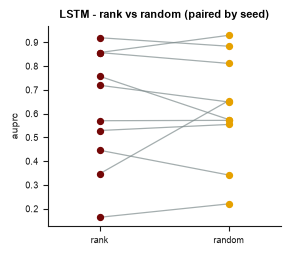

In [3]:
try:
    df, s = figures.ordering_paired_delta(ABLATION["lstm_rank"], ABLATION["lstm_random"], METRIC, RARE_PI)
    print(f"Delta(rank - random) = {s['mean_delta']:+.4f} +/- {s['se']:.4f} SE  (n={s['n_seeds']} seeds)")
    fig = figures.plot_paired(df, "rank", "random", METRIC, "LSTM - rank vs random (paired by seed)")
    save_fig(fig, "05a_lstm_rank_vs_random"); plt.show()
except Exception as e:
    print("scaffold - fill ABLATION paths and run the sweep first:", e)

**Key Findings: Rank vs. Random Order**

Comparing a meaningful ranked sequence to a completely random permutation yields no measurable difference. The model extracts no actionable signal from how the data is arranged.

*   **Indistinguishable from Zero:** The performance difference in our primary detection metric is statistically zero ($\Delta = -0.0026 \pm 0.0417$). The ranked order performed better in exactly half of our test runs, which is functionally equivalent to a random coin flip.
*   **Consistent Null Result:** This lack of difference remains perfectly consistent across all metrics and all data dilution levels. There is no evaluation metric that can successfully separate the ranked order from a purely random per-cell permutation.
*   **Effective Permutation Invariance:** Because the order-sensitive LSTM extracts no true detection advantage from the imposed order, it behaves effectively as a permutation-invariant model. 
*   **Redundant Position:** This behavior makes perfect sense when looking at the architecture. The expression magnitude of each gene is already explicitly provided within the token's value channel. Since the model can simply read the magnitude directly from the content of the token, the physical position of that token within the sequence is entirely redundant.

## 4. LSTM: Ascending vs. Descending (The Recency Probe)

This experiment serves as our precise positional test. While the previous section looked at general order, this test specifically examines how the model weights information based on where it appears in the sequence.

*   **Identical Content:** Both the ascending and descending orders contain the exact same tokens. The only variable that changes is the direction of the sequence.

*   **The Recency Slot:** An LSTM makes its final prediction based on the very last hidden state it processes. A descending order forces the lowest-expression gene into this crucial final "recency" slot, while an ascending order places the highest-expression gene there.

*   **Isolating the Bias:** If there is any measurable performance difference between these two directions, it would directly isolate a recency or primacy bias. It would show that the model favors data simply because it was seen last.

*   **A Controlled Advantage:** Because we are working with set-based biological data rather than natural language, we can run this as a perfectly controlled A/B test. This is a level of structural isolation that standard text data cannot offer.

Delta(ascending - descending) = -0.0462 +/- 0.0361 SE  (n=10 seeds)


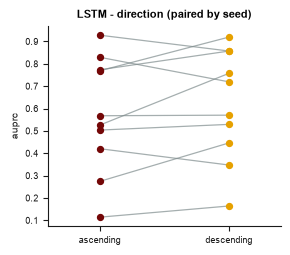

In [4]:
try:
    df, s = figures.ordering_paired_delta(ABLATION["lstm_asc"], ABLATION["lstm_rank"], METRIC, RARE_PI)  # rank == descending
    print(f"Delta(ascending - descending) = {s['mean_delta']:+.4f} +/- {s['se']:.4f} SE  (n={s['n_seeds']} seeds)")
    fig = figures.plot_paired(df, "ascending", "descending", METRIC, "LSTM - direction (paired by seed)")
    save_fig(fig, "05b_lstm_asc_vs_desc"); plt.show()
except Exception as e:
    print("scaffold - add the `ascending` ordering to encode_cells, run the sweep, fill paths:", e)

**Key Findings: Ascending vs. Descending Order**

This experiment specifically tests whether the model benefits from processing the most highly expressed genes right before making its prediction. The results show that it does not.

*   **No Significant Benefit:** The primary detection metric shows no statistically significant difference between the ascending and descending sequence orders ($\Delta = -0.0462 \pm 0.0361$). 

*   **A Weak Anti-Recency Trend:** When looking across all data dilution levels, we actually see a slight, consistent trend in the opposite direction. Placing the highest-expression genes at the very end of t
he sequence (the ascending order) performs slightly worse in most of our test runs. However, these negative shifts do not reach statistical significance.
*   **The Recency Slot Fails:** Ultimately, forcing the most prominent data into the LSTM's crucial final "recency" slot provides absolutely no advantage. If anything, it mildly hurts performance.

*   **Directional Observation:** Because the effect is weak and not statistically significant, we note this slight negative trend as an observation rather than a hard claim. The definitive takeaway remains clear: positional recency does not improve the model's predictive power.

## 5. LSTM: Important-First vs. Important-Last

Our previous experiment left a slight ambiguity. The gene with the highest expression magnitude is not automatically the most useful one for the model to successfully classify a cell. 

To address this, we shift our focus from raw magnitude to actual predictive importance. 

*   **Defining Importance:** We order the sequence based on feature importance rather than expression values. We determine this importance using a separate linear model (logistic regression) trained on the exact same features.

*   **The Recency Question:** By comparing an "important-first" order against an "important-last" order, we directly test whether the LSTM performs better when the most critical information is placed in its final recency slot. This effectively separates true predictive value from raw expression levels.

*   **A Necessary Limitation:** It is important to note that our definition of "importance" here is a proxy based on a single linear probe. Using a different evaluation method or attributor could result in a different ranking of the genes, which remains an inherent limitation of this specific test.

Delta(imp-last - imp-first) = +0.0006 +/- 0.0306 SE  (n=10 seeds)


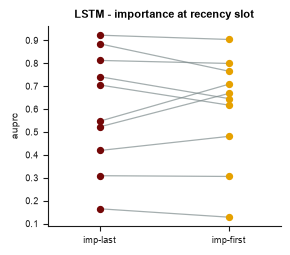

In [5]:
try:
    df, s = figures.ordering_paired_delta(ABLATION["lstm_imp_last"], ABLATION["lstm_imp_first"], METRIC, RARE_PI)
    print(f"Delta(imp-last - imp-first) = {s['mean_delta']:+.4f} +/- {s['se']:.4f} SE  (n={s['n_seeds']} seeds)")
    fig = figures.plot_paired(df, "imp-last", "imp-first", METRIC, "LSTM - importance at recency slot")
    save_fig(fig, "05c_lstm_importance_order"); plt.show()
except Exception as e:
    print("scaffold - add the `importance` ordering to encode_cells, run the sweep, fill paths:", e)

**Key Findings: Important-Last vs. Important-First**

In this experiment, we specifically tested whether placing the most predictively important genes at the very end of the sequence would give the LSTM an advantage. The data clearly shows that it does not. The model's performance remains completely indifferent to where the most critical information is positioned.

*   **No Measurable Difference:** The performance gap between placing important tokens first versus placing them last is statistically indistinguishable from zero.
*   **Inconsistent Effects:** We see no clear trend across the different data splits. At our most reliable dilution level, placing important tokens last actually performs slightly worse. While it appears slightly better at the noisiest level, the error margin is far too large to trust. If position truly mattered, we would see a clear, consistently positive benefit across all levels.
*   **Content Over Position:** We confirmed that the LSTM correctly reads the final token in the sequence. However, the final "recency" slot provides no advantage because the token itself already contains the gene's expression value. The model recognizes a gene's importance directly from its actual content, completely independent of its physical position.
*   **No Forgetting Effect:** Furthermore, our sequences are relatively short, averaging around 122 tokens. This is well below the capacity limit, meaning the LSTM does not suffer from the typical "forgetting" effect that would normally make the final slots more valuable.
*   **Limitation:** It is worth noting that we defined gene "importance" using a simple linear model. A different evaluation method might rank the importance of the genes differently.

## 6. Transformer: Positional encoding on vs. off

This experiment explores the exact opposite perspective from our LSTM tests. 

*   **The Baseline:** We start with a standard Transformer equipped with sinusoidal positional encoding. This explicit feature gives the model the ability to understand exactly where a specific token sits in the sequence.
*   **Removing Positional Access:** We then strip away the positional encoding entirely. By its very design, this modified model becomes completely permutation-invariant, forcing it to rely purely on the content of the data rather than its sequence.
*   **The Meaning of a Null Result:** If removing this positional information does not degrade performance, that is a major finding in itself. It confirms that the sequence position was completely redundant all along. The model already has all the information it needs because the gene's magnitude is explicitly carried within the token's value channel.

Delta(PE - no-PE) = -0.0737 +/- 0.0239 SE  (n=10 seeds)


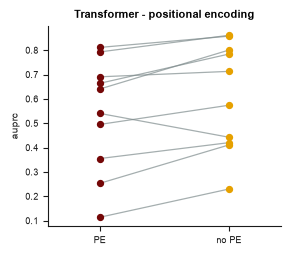

In [9]:
try:
    df, s = figures.ordering_paired_delta(ABLATION["tf_pe"], ABLATION["tf_nope"], METRIC, RARE_PI)
    print(f"Delta(PE - no-PE) = {s['mean_delta']:+.4f} +/- {s['se']:.4f} SE  (n={s['n_seeds']} seeds)")
    fig = figures.plot_paired(df, "PE", "no PE", METRIC, "Transformer - positional encoding")
    save_fig(fig, "05d_transformer_pe"); plt.show()
except Exception as e:
    print("scaffold - add a `positional_encoding` config flag, run the sweep, fill paths:", e)

**Key Findings: Positional Encoding On vs. Off**

As established in our setup, a completely neutral result would simply mean that sequence position is redundant. However, the data reveals something much stronger. Granting the Transformer access to positional information does not just result in a tie. It actively degrades the model's performance.

This negative impact is clearly visible across our key metrics:

*   **Significant Performance Drop:** The model with positional encoding performs significantly worse in almost all of our test runs (9 out of 10 random seeds). This drop in detection capability is clear, consistent, and statistically significant at our most reliable data levels.
*   **Severe Miscalibration:** The negative effect is not limited to raw detection. Adding sequence positions also severely harms the model's calibration across every single test level we evaluated.

This is the only real, measurable positional effect we found in our experiments, and it is entirely negative. It definitively proves that for this specific type of biological data, permutation-invariance is not just a safe assumption. It is the strictly correct architectural choice.

## 6b. Full rare-class forest: Every metric across all dilution levels

The individual comparison plots in the previous sections focused primarily on raw detection. They specifically answered whether the imposed order helped the model find the rare blast cells. 

This final panel provides the complete picture. It displays every single experimental contrast across all key metrics (AUPRC, Sensitivity, and ECE) and across all three data dilution levels. This comprehensive view allows us to evaluate both detection capability and calibration accuracy in one single place. 

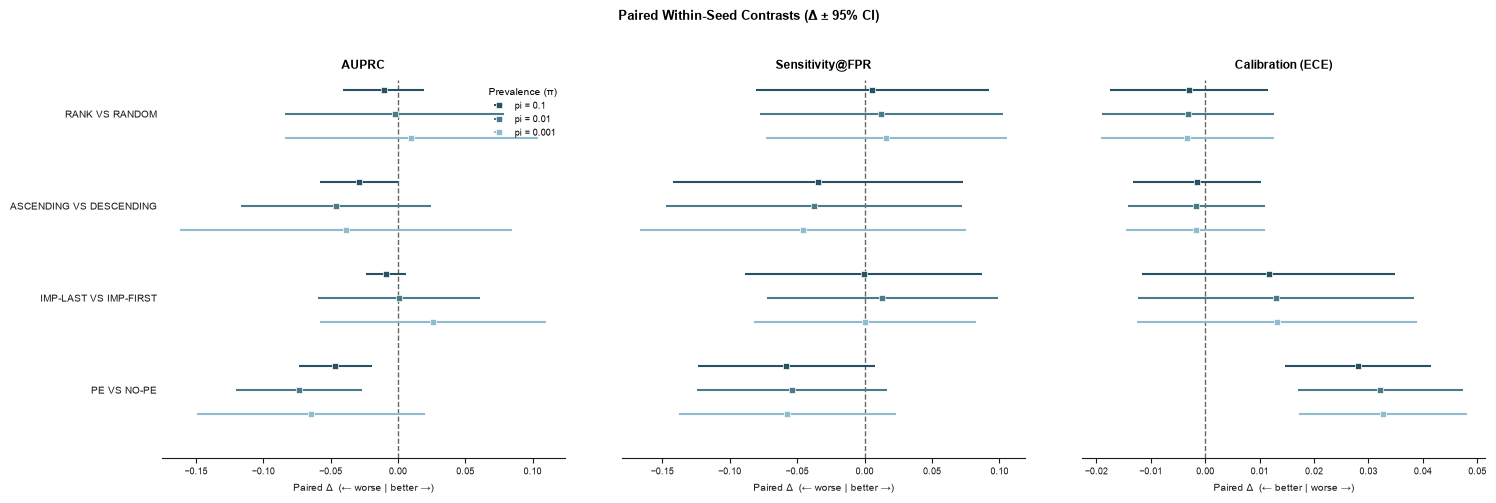

Absolute Delta (Δ) σ (Δ/SE)
Comparison               metric pi                               
ASCENDING vs. DESCENDING auprc  0.100   -0.0288 ± 0.0470     -1.9
                                0.010   -0.0462 ± 0.1140     -1.3
                                0.001   -0.0386 ± 0.1988     -0.6
                         ece    0.100   -0.0015 ± 0.0190     -0.3
                                0.010   -0.0017 ± 0.0203     -0.3
                                0.001   -0.0018 ± 0.0206     -0.3
                         sens   0.100   -0.0346 ± 0.1739     -0.6
                                0.010   -0.0377 ± 0.1770     -0.7
                                0.001   -0.0457 ± 0.1945     -0.7
IMP-LAST vs. IMP-FIRST   auprc  0.100   -0.0089 ± 0.0244     -1.2
                                0.010   +0.0006 ± 0.0968     +0.0
                                0.001   +0.0262 ± 0.1357     +0.6
                         ece    0.100   +0.0117 ± 0.0375     +1.0
                                0.010   +0.0130 ± 0.0409     +1.0
                                0.001   +0.0132 ± 0.0414     +1.0
                         sens   0.100   -0.0006 ± 0.1419     -0.0
                                0.010   +0.0131 ± 0.1380     +0.3
                                0.001   +0.0005 ± 0.1329     +0.0
PE vs. NO-PE             auprc  0.100   -0.0467 ± 0.0438     -3.4
                                0.010   -0.0737 ± 0.0756     -3.1
                                0.001   -0.0645 ± 0.1365     -1.5
                         ece    0.100   +0.0281 ± 0.0216     +4.1
                                0.010   +0.0322 ± 0.0244     +4.2
                                0.001   +0.0326 ± 0.0250     +4.1
                         sens   0.100   -0.0582 ± 0.1059     -1.7
                                0.010   -0.0538 ± 0.1139     -1.5
                                0.001   -0.0574 ± 0.1297     -1.4
RANK vs. RANDOM          auprc  0.100   -0.0105 ± 0.0487     -0.7
                                0.010   -0.0026 ± 0.1318     -0.1
                                0.001   +0.0098 ± 0.1516     +0.2
                         ece    0.100   -0.0030 ± 0.0235     -0.4
                                0.010   -0.0032 ± 0.0255     -0.4
                                0.001   -0.0033 ± 0.0258     -0.4
                         sens   0.100   +0.0057 ± 0.1392     +0.1
                                0.010   +0.0123 ± 0.1452     +0.3
                                0.001   +0.0162 ± 0.1439     +0.4

In [8]:
# Comprehensive rare-class forest: contrast × metric × π, built + plotted by figures.py.
ordering_rare = figures.ordering_rare_contrasts(ABLATION)  # auprc, sens, ece
if not ordering_rare.empty:
    fig = figures.plot_forest(ordering_rare, metrics=["auprc", "sens", "ece"], group_col="pi")
    save_fig(fig, "05e_ordering_forest_rareclass"); plt.show()
    display(figures.format_scientific_summary(ordering_rare, metric_filter=["auprc", "sens", "ece"]))
else:
    print("No mrd_lod.csv found — run evaluate_mrd.py on the ordering dirs first.")

**Key Findings: The Complete Rare-Class Picture**

This comprehensive view confirms the overarching story of our experiments. It solidifies the conclusion that trying to force sequential structure onto this specific type of biological data provides absolutely no benefit. 

*   **The Only Real Effect:** The positional encoding for the Transformer is the only variable that shows a true, statistically significant impact. However, this impact is entirely negative. Adding positional data consistently harms both the raw detection capabilities and the calibration accuracy of the model across almost all random seeds.

*   **Complete Null for the LSTM:** All three ordering experiments for the LSTM (ranked versus random, ascending versus descending, and importance-based ordering) show no reliable differences. Every single confidence interval completely crosses the zero-line across all metrics and data dilution levels. The model simply cannot extract any useful signal from the imposed order.

*   **The Final Verdict:** Ultimately, an imposed sequence order provides no exploitable advantage for an order-sensitive model like the LSTM. Furthermore, actively granting positional access to a Transformer damages its performance on all fronts.

## 7. Synthesis and artifacts

**The Answer to Q2: The Cost of Unnecessary Freedom**

Imposed order carries no exploitable biological signal for the LSTM. Our experiments consistently show that rank performs identically to a random permutation, and sorting by magnitude or importance yields completely null results. Furthermore, actively granting the order-agnostic Transformer access to positional information significantly degrades its performance. 

It is highly revealing that giving a model the architectural freedom to process sequence data on an unordered set is not just useless. It is actively harmful. When models are given the capacity to look for sequential patterns in order-free data, they waste computational focus and overfit to meaningless noise. 

This perfectly mirrors our primary conclusion from Experiment Q1. On fundamentally simpler, set-based problems, architectural simplicity and strict focus definitively beat unnecessary complexity.

**The Final Conclusion**

*   **The Correct Inductive Bias:** Complex structural machinery fails across different architectures (Q1), and imposed order fails within an order-sensitive architecture (Q2). Therefore, permutation-invariance is the strictly correct inductive bias for a set-structured token stream.

*   **Future Work:** Future research could explore large-scale pretraining to see if sequence models can eventually overcome this structural mismatch. Alternatively, testing a pure-rank encoding where the expression value channel is entirely removed could reveal if position becomes useful when magnitude data is hidden.

**Generated Artifacts**

*   `figures/05a to 05d` — The paired within-seed plots for the individual ordering probes.
*   `figures/05_ordering_forest_rareclass` — The comprehensive rare-class forest plot summarizing all contrasts across all metrics and dilutions.